# Step 1 — EDA + User Contention 偵測

**目標**：了解四段耗時分佈 + 偵測同 device 短時間多單的 contention

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
print(f"Loaded {len(df):,} orders, {df['device_id'].nunique()} devices")


Loaded 30,000 orders, 200 devices


## Part A — EDA: 四段耗時分佈

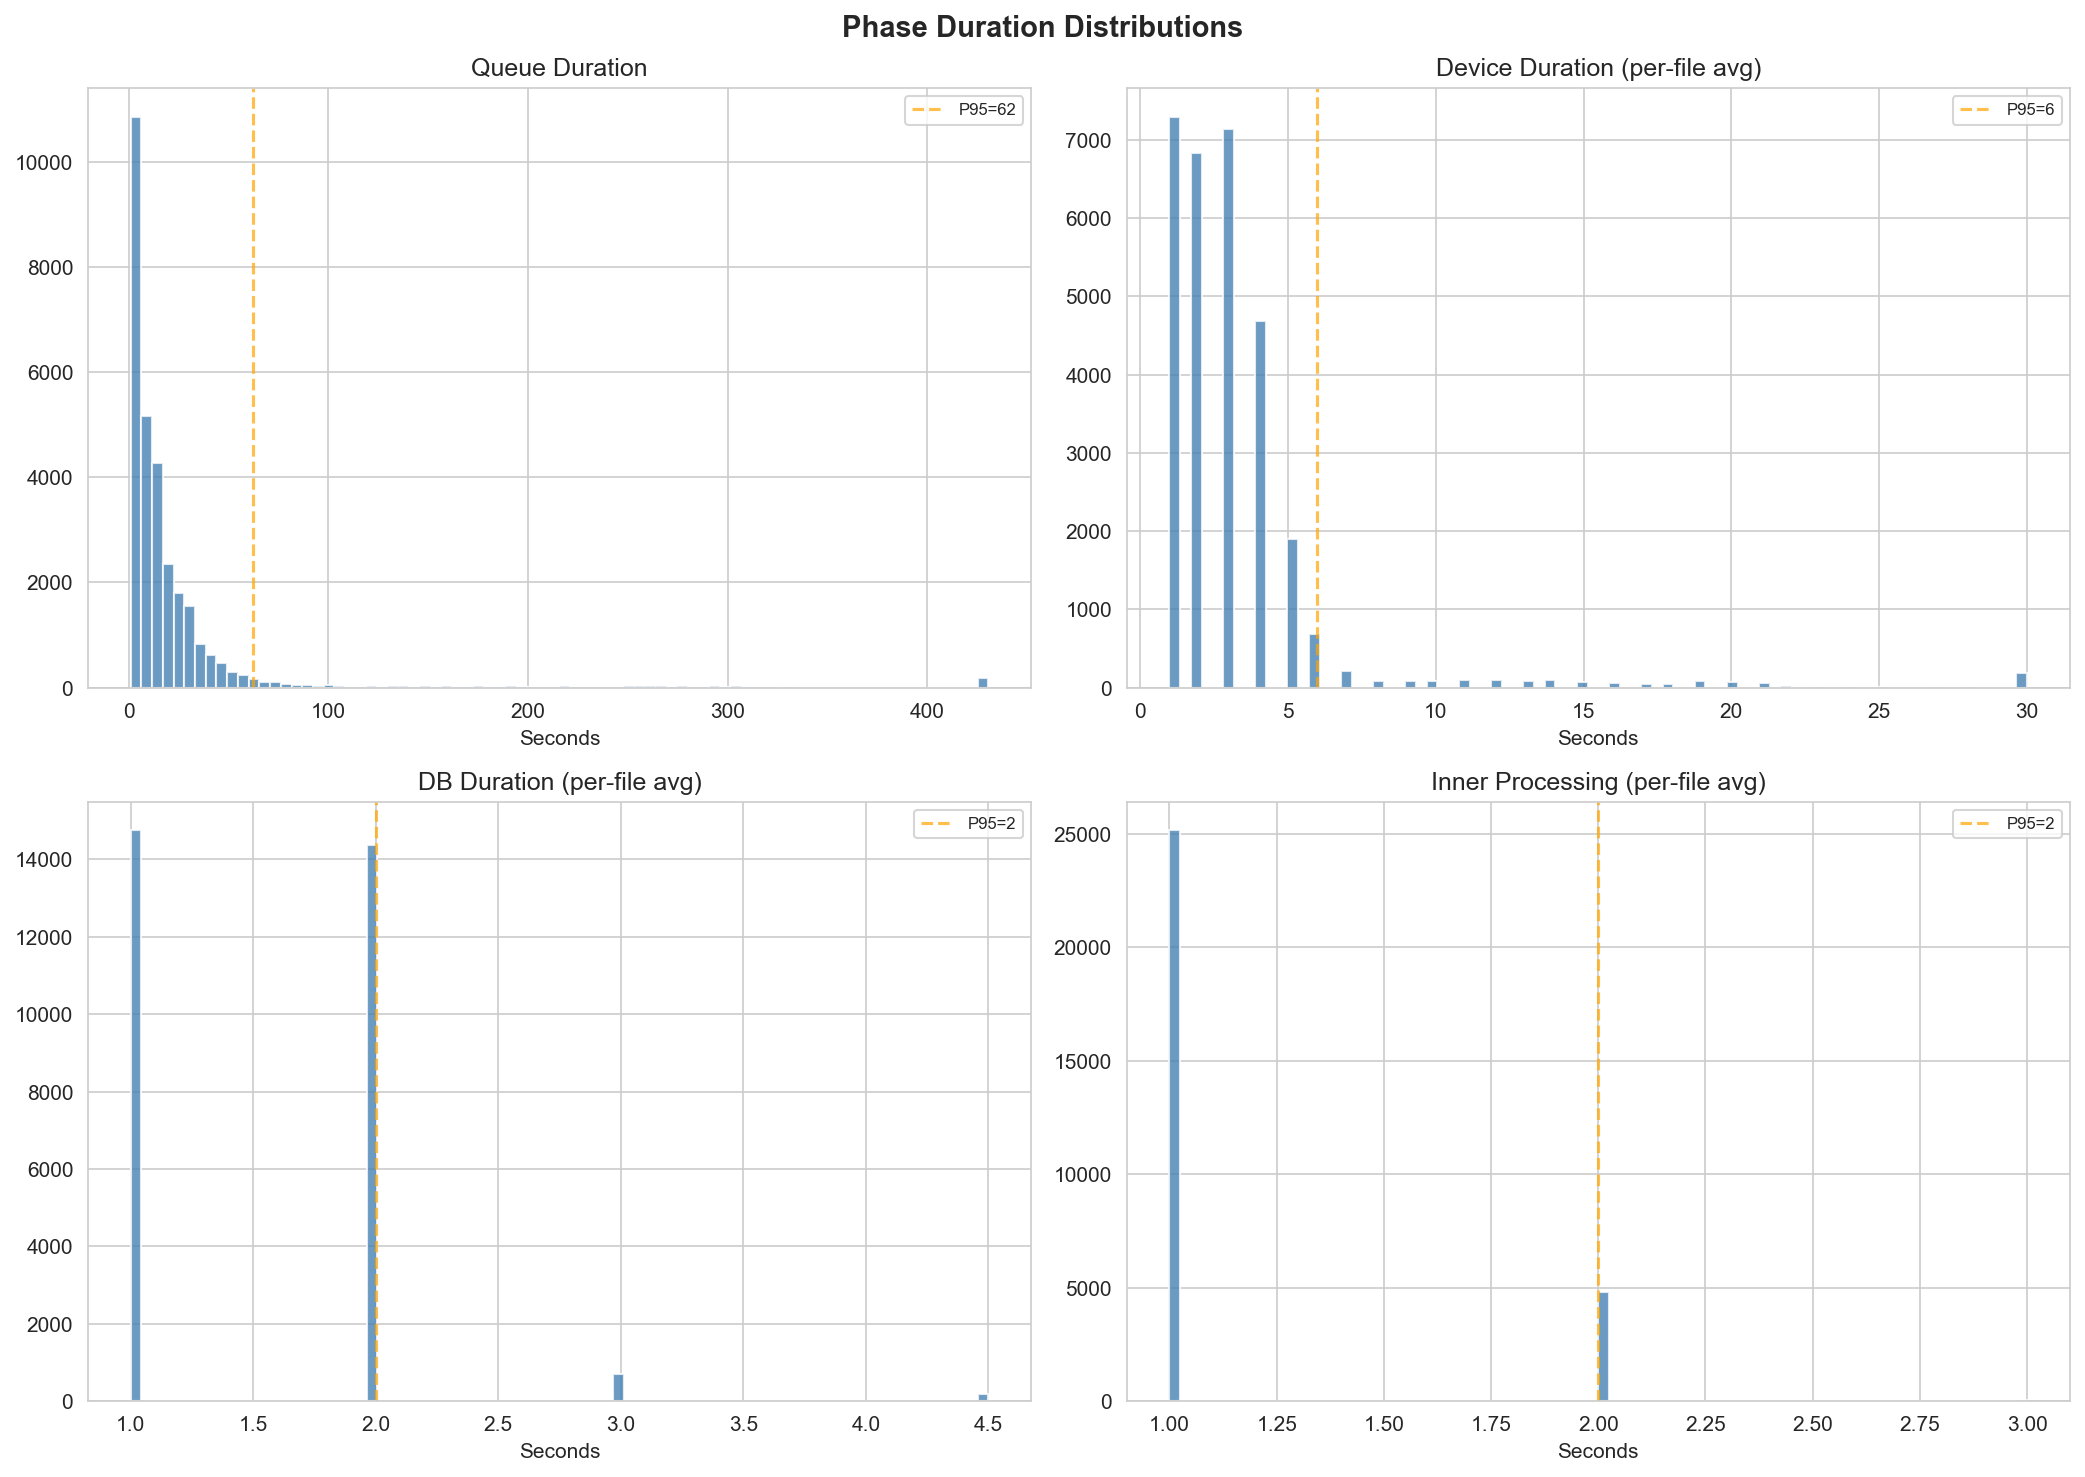

Queue Duration: P50=10, P75=22, P95=62, P99=287, max=3631
Device Duration (per-file avg): P50=3, P75=4, P95=6, P99=20, max=599
DB Duration (per-file avg): P50=2, P75=2, P95=2, P99=3, max=150
Inner Processing (per-file avg): P50=1, P75=1, P95=2, P99=2, max=3


In [3]:
# 4-panel phase histograms
phase_cols = {
    'queue_duration_seconds': 'Queue Duration',
    'device_duration_avg_seconds': 'Device Duration (per-file avg)',
    'db_duration_avg_seconds': 'DB Duration (per-file avg)',
    'inner_processing_duration_avg_seconds': 'Inner Processing (per-file avg)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (col, title) in enumerate(phase_cols.items()):
    ax = axes[idx // 2][idx % 2]
    data = df[col].clip(upper=df[col].quantile(0.99) * 1.5)
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Seconds')
    pcts = df[col].quantile([0.5, 0.95, 0.99])
    ax.axvline(x=pcts[0.95], color='orange', linestyle='--', alpha=0.7, label=f'P95={pcts[0.95]:.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Phase Duration Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_phase_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print percentiles
for col, title in phase_cols.items():
    pcts = df[col].quantile([0.5, 0.75, 0.95, 0.99])
    print(f"{title}: P50={pcts[0.5]:.0f}, P75={pcts[0.75]:.0f}, P95={pcts[0.95]:.0f}, P99={pcts[0.99]:.0f}, max={df[col].max()}")


file_count: P25=43, P50=215, P75=714, P95=1897, P99=4256, max=4996


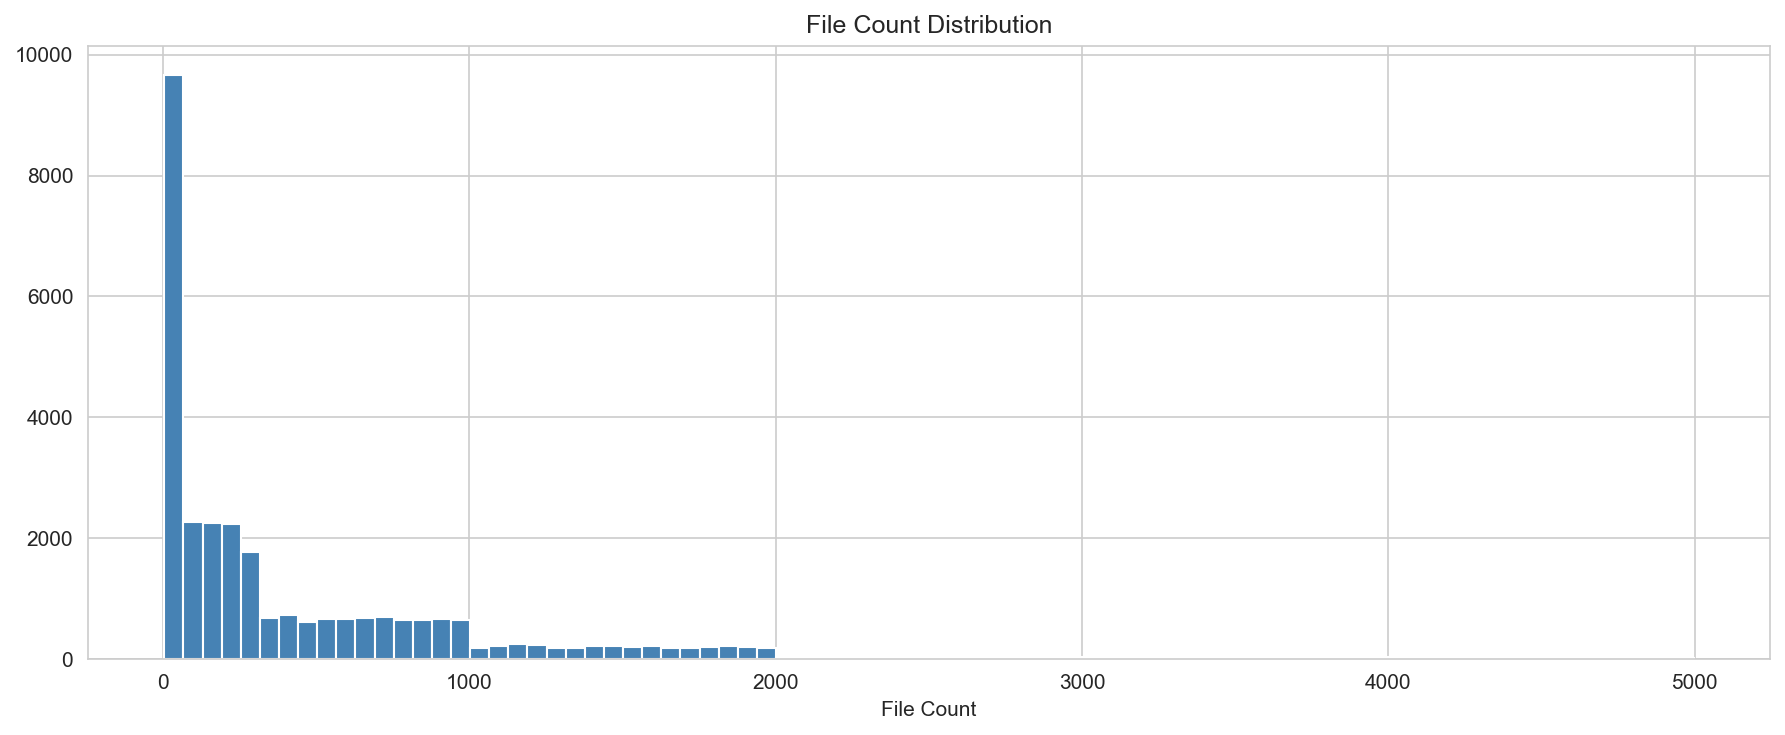

In [4]:
# file_count distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['file_count'].clip(upper=df['file_count'].quantile(0.99)*1.2), bins=80,
        color='steelblue', edgecolor='white')
ax.set_title('File Count Distribution')
ax.set_xlabel('File Count')
pcts = df['file_count'].quantile([0.25, 0.5, 0.75, 0.95, 0.99])
print(f"file_count: P25={pcts[0.25]:.0f}, P50={pcts[0.5]:.0f}, P75={pcts[0.75]:.0f}, "
      f"P95={pcts[0.95]:.0f}, P99={pcts[0.99]:.0f}, max={df['file_count'].max()}")
plt.tight_layout()
plt.show()


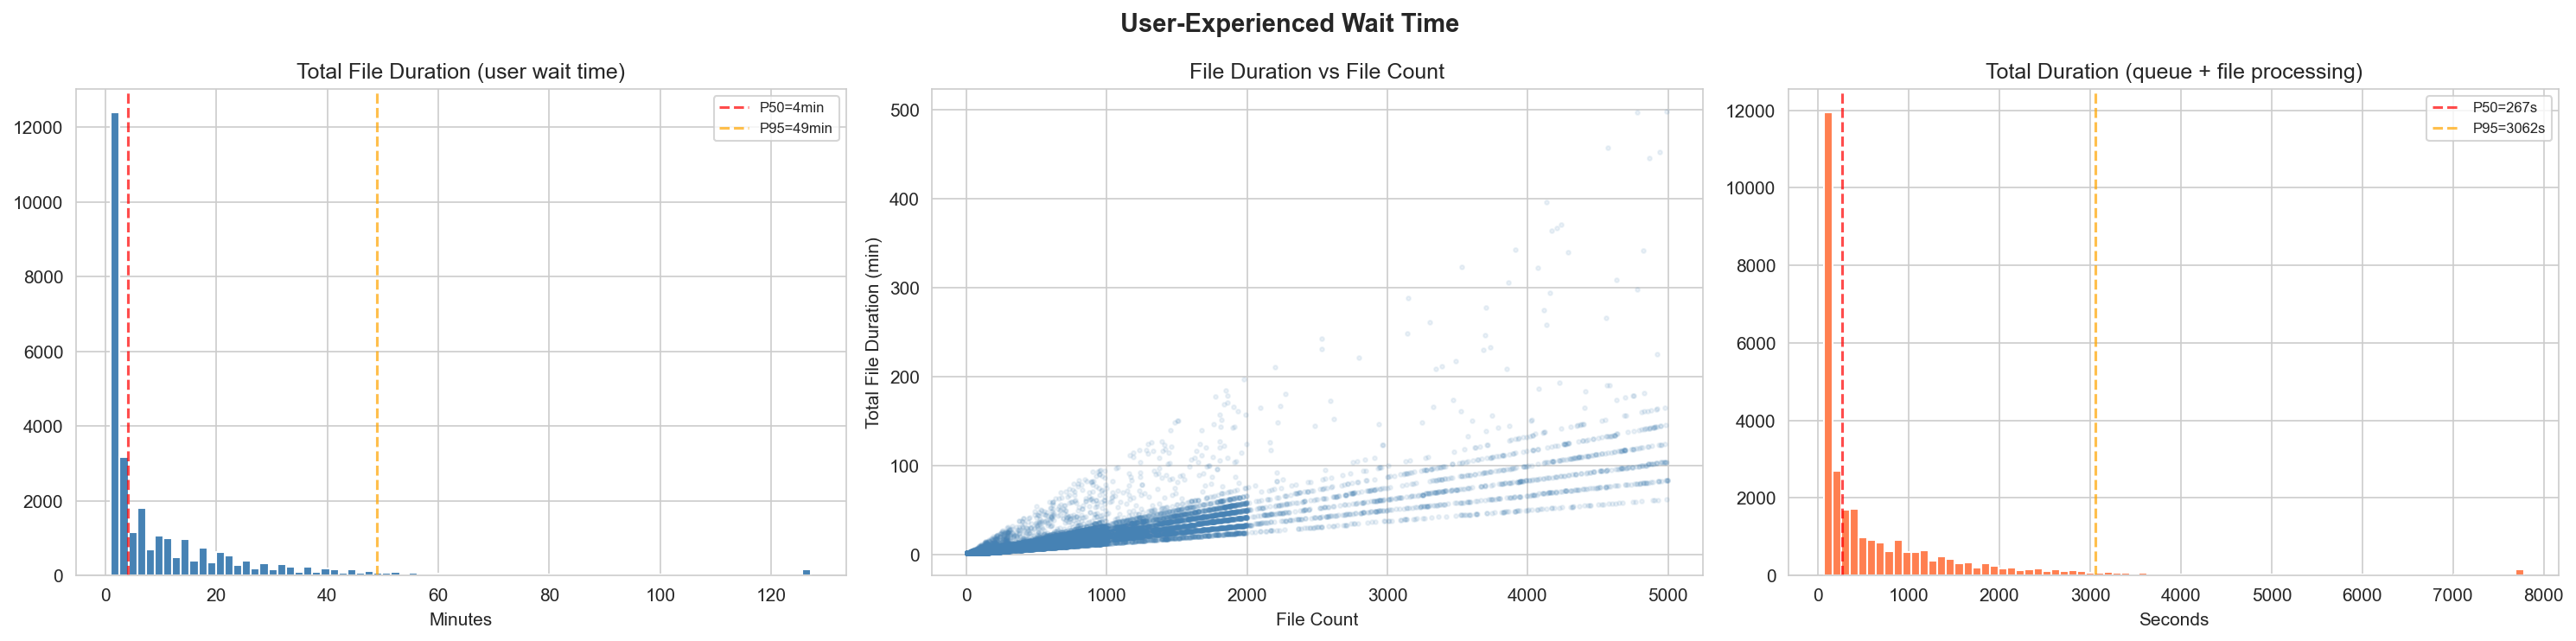

total_file_duration_minutes: P50=4, P95=49, P99=106, max=498
total_duration_seconds: P50=267s (4.5min), P95=3062s (51.0min)

30分鐘內完成: 26,409 (88.0%)
超過1小時: 1,119 (3.7%)


In [5]:
# User-experienced duration: total_file_duration_minutes + total_duration_seconds
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Left: total_file_duration_minutes
ax = axes[0]
ax.hist(df['total_file_duration_minutes'].clip(upper=df['total_file_duration_minutes'].quantile(0.99)*1.2),
        bins=80, color='steelblue', edgecolor='white')
pcts = df['total_file_duration_minutes'].quantile([0.5, 0.95])
ax.axvline(x=pcts[0.5], color='red', linestyle='--', alpha=0.7, label=f'P50={pcts[0.5]:.0f}min')
ax.axvline(x=pcts[0.95], color='orange', linestyle='--', alpha=0.7, label=f'P95={pcts[0.95]:.0f}min')
ax.set_title('Total File Duration (user wait time)')
ax.set_xlabel('Minutes')
ax.legend(fontsize=8)

# Middle: total_file_duration vs file_count
ax = axes[1]
ax.scatter(df['file_count'], df['total_file_duration_minutes'], alpha=0.1, s=5, c='steelblue')
ax.set_title('File Duration vs File Count')
ax.set_xlabel('File Count')
ax.set_ylabel('Total File Duration (min)')

# Right: total_duration_seconds (includes queue)
ax = axes[2]
ax.hist(df['total_duration_seconds'].clip(upper=df['total_duration_seconds'].quantile(0.99)*1.2),
        bins=80, color='coral', edgecolor='white')
pcts_total = df['total_duration_seconds'].quantile([0.5, 0.95])
ax.axvline(x=pcts_total[0.5], color='red', linestyle='--', alpha=0.7, label=f'P50={pcts_total[0.5]:.0f}s')
ax.axvline(x=pcts_total[0.95], color='orange', linestyle='--', alpha=0.7, label=f'P95={pcts_total[0.95]:.0f}s')
ax.set_title('Total Duration (queue + file processing)')
ax.set_xlabel('Seconds')
ax.legend(fontsize=8)

plt.suptitle('User-Experienced Wait Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_user_wait_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"total_file_duration_minutes: P50={df['total_file_duration_minutes'].median():.0f}, "
      f"P95={df['total_file_duration_minutes'].quantile(0.95):.0f}, "
      f"P99={df['total_file_duration_minutes'].quantile(0.99):.0f}, "
      f"max={df['total_file_duration_minutes'].max()}")
print(f"total_duration_seconds: P50={df['total_duration_seconds'].median():.0f}s "
      f"({df['total_duration_seconds'].median()/60:.1f}min), "
      f"P95={df['total_duration_seconds'].quantile(0.95):.0f}s "
      f"({df['total_duration_seconds'].quantile(0.95)/60:.1f}min)")
print(f"\n30分鐘內完成: {(df['total_duration_seconds'] <= 1800).sum():,} ({100*(df['total_duration_seconds'] <= 1800).mean():.1f}%)")
print(f"超過1小時: {(df['total_duration_seconds'] > 3600).sum():,} ({100*(df['total_duration_seconds'] > 3600).mean():.1f}%)")


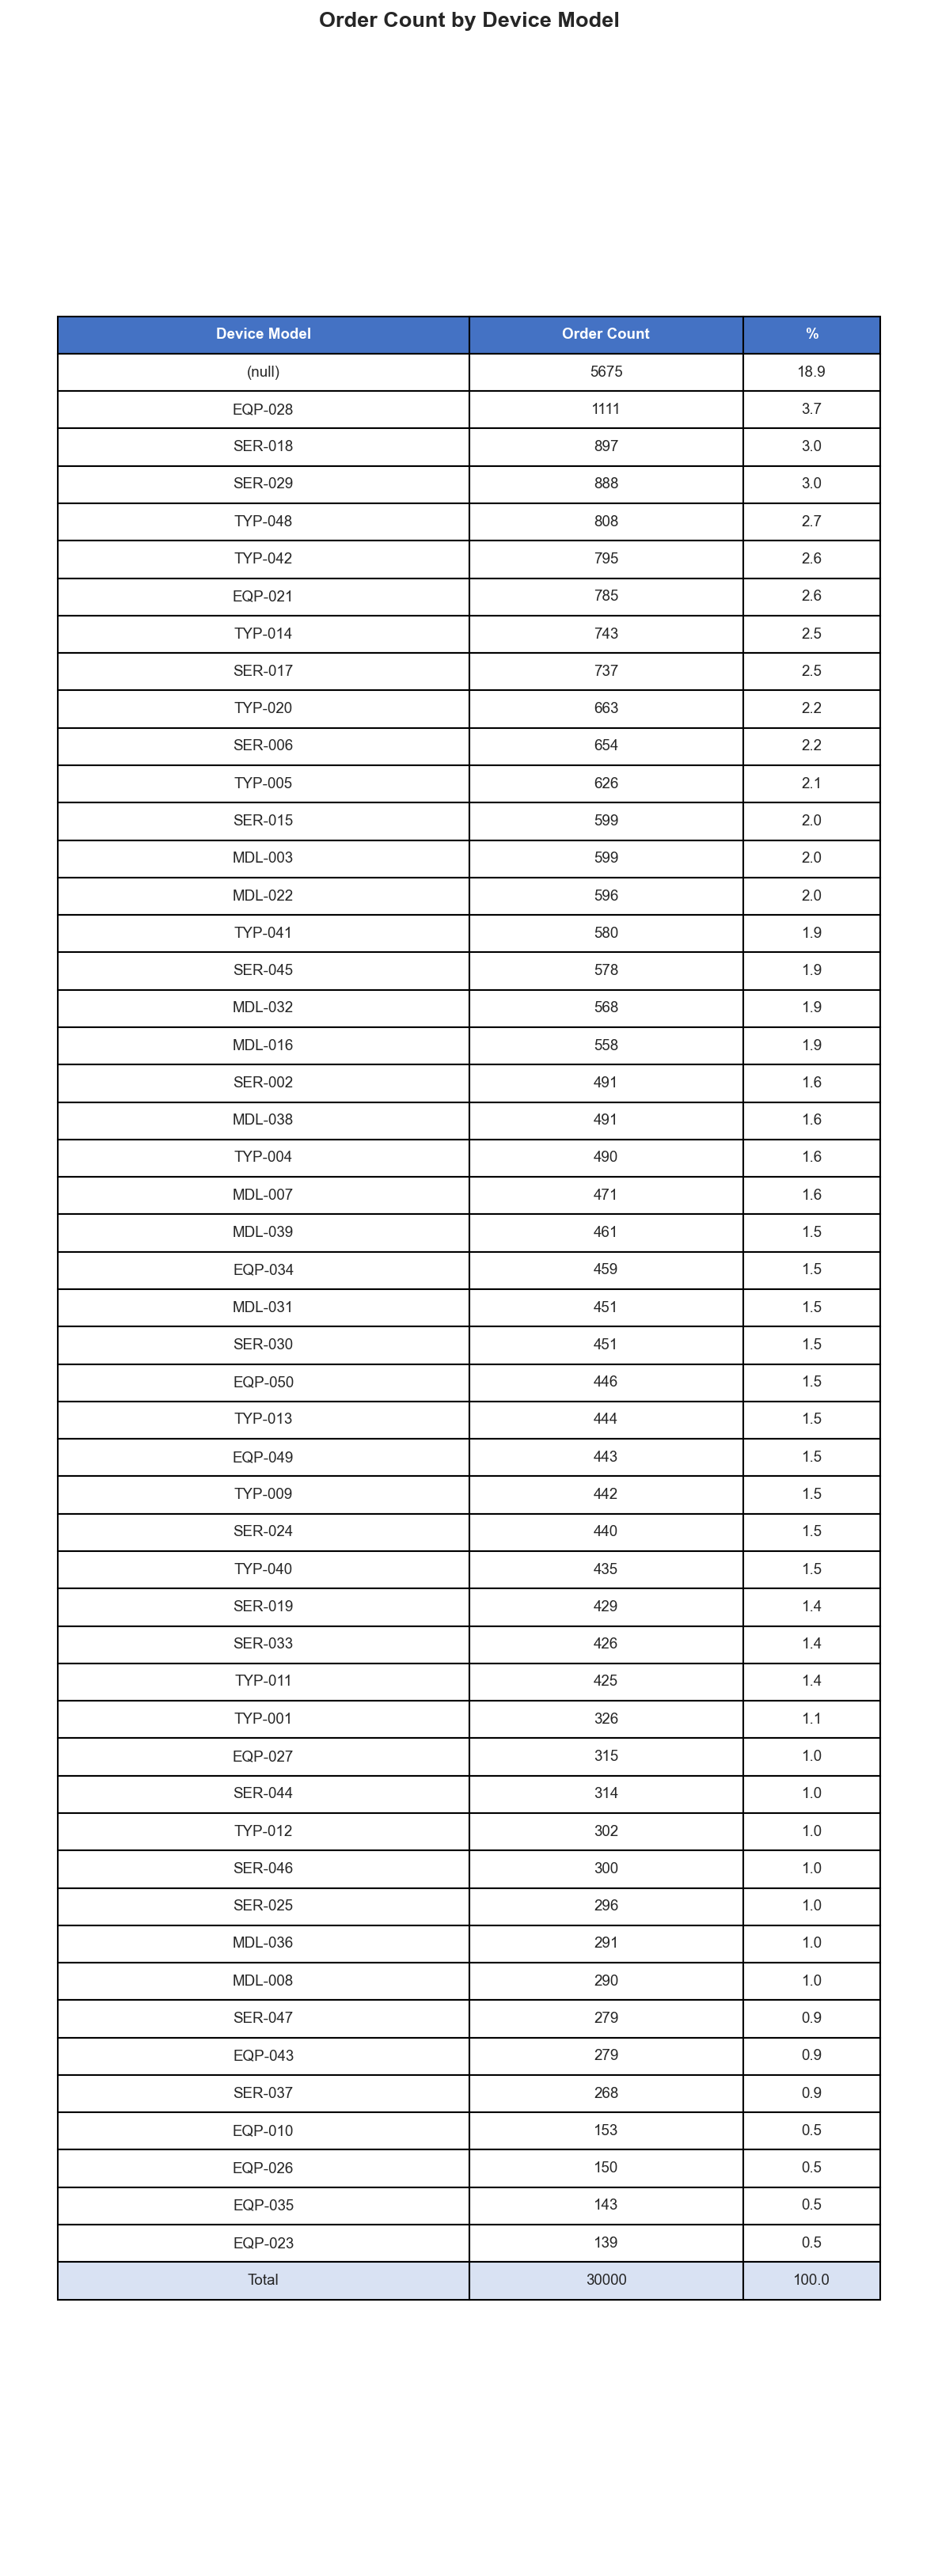

Device models: 50 types + 18.9% null


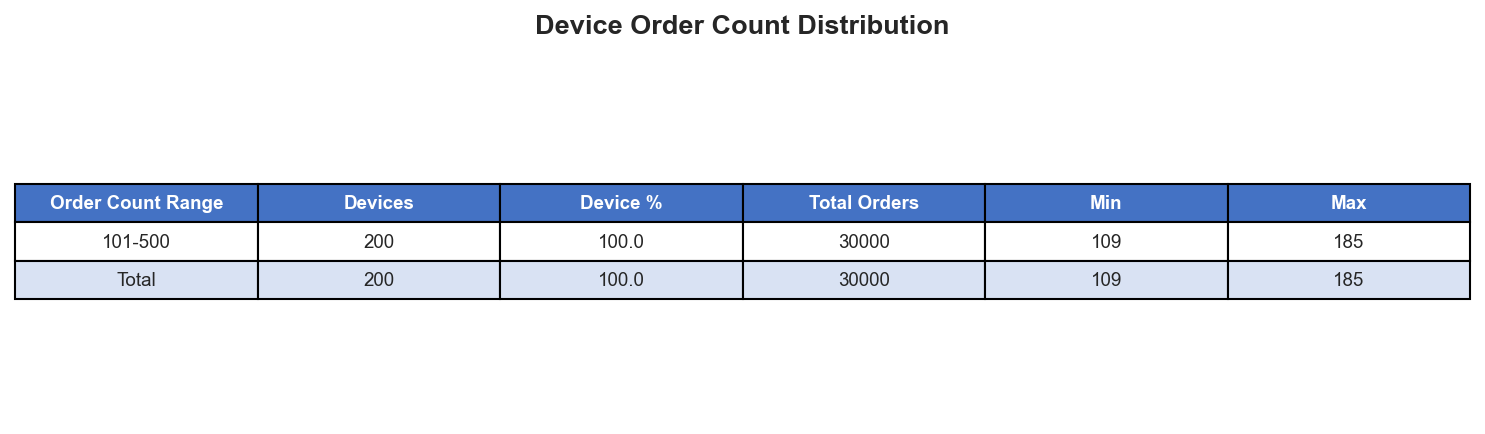

Devices: 200, median orders/device: 150
Devices with ≤5 orders: 0


In [6]:
# Device Model & Device Order Distribution (table images)

# --- Table 1: Order count by device model ---
model_counts = df['device_mode_name'].fillna('(null)').value_counts().reset_index()
model_counts.columns = ['Device Model', 'Order Count']
model_counts['%'] = (model_counts['Order Count'] / model_counts['Order Count'].sum() * 100).round(1)
# Add total row
total_row = pd.DataFrame([{'Device Model': 'Total', 'Order Count': model_counts['Order Count'].sum(), '%': 100.0}])
model_table = pd.concat([model_counts, total_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, max(3, len(model_table) * 0.4 + 1)))
ax.axis('off')
ax.set_title('Order Count by Device Model', fontsize=13, fontweight='bold', pad=15)
tbl = ax.table(cellText=model_table.values.tolist(),
               colLabels=model_table.columns.tolist(),
               cellLoc='center', loc='center', colWidths=[0.45, 0.3, 0.15])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for j in range(len(model_table.columns)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
tbl[len(model_table), 0].set_facecolor('#D9E2F3')
tbl[len(model_table), 1].set_facecolor('#D9E2F3')
tbl[len(model_table), 2].set_facecolor('#D9E2F3')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_device_model_order_dist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

null_pct = df['device_mode_name'].isnull().mean() * 100
print(f"Device models: {df['device_mode_name'].nunique()} types + {null_pct:.1f}% null")

# --- Table 2: Order count distribution by device ---
device_counts = df.groupby('device_id').size().reset_index(name='order_count')
bins = [0, 1, 5, 10, 20, 50, 100, 500, device_counts['order_count'].max() + 1]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-500', '500+']
# Remove unused upper bins
while bins[-1] <= bins[-2]:
    bins.pop()
    labels.pop()
device_counts['range'] = pd.cut(device_counts['order_count'], bins=bins, labels=labels[:len(bins)-1], right=True)

dist = device_counts.groupby('range', observed=True).agg(
    devices=('device_id', 'count'),
    total_orders=('order_count', 'sum'),
    min_orders=('order_count', 'min'),
    max_orders=('order_count', 'max'),
).reset_index()
dist.columns = ['Order Count Range', 'Devices', 'Total Orders', 'Min', 'Max']
dist['Device %'] = (dist['Devices'] / dist['Devices'].sum() * 100).round(1)
dist = dist[['Order Count Range', 'Devices', 'Device %', 'Total Orders', 'Min', 'Max']]

# Add total
total_row2 = pd.DataFrame([{
    'Order Count Range': 'Total',
    'Devices': dist['Devices'].sum(),
    'Device %': 100.0,
    'Total Orders': dist['Total Orders'].sum(),
    'Min': device_counts['order_count'].min(),
    'Max': device_counts['order_count'].max(),
}])
dist_table = pd.concat([dist, total_row2], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, max(3, len(dist_table) * 0.45 + 1)))
ax.axis('off')
ax.set_title('Device Order Count Distribution', fontsize=13, fontweight='bold', pad=15)
tbl = ax.table(cellText=dist_table.values.tolist(),
               colLabels=dist_table.columns.tolist(),
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for j in range(len(dist_table.columns)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for j in range(len(dist_table.columns)):
    tbl[len(dist_table), j].set_facecolor('#D9E2F3')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_device_order_dist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Devices: {len(device_counts)}, median orders/device: {device_counts['order_count'].median():.0f}")
print(f"Devices with ≤5 orders: {(device_counts['order_count'] <= 5).sum()}")


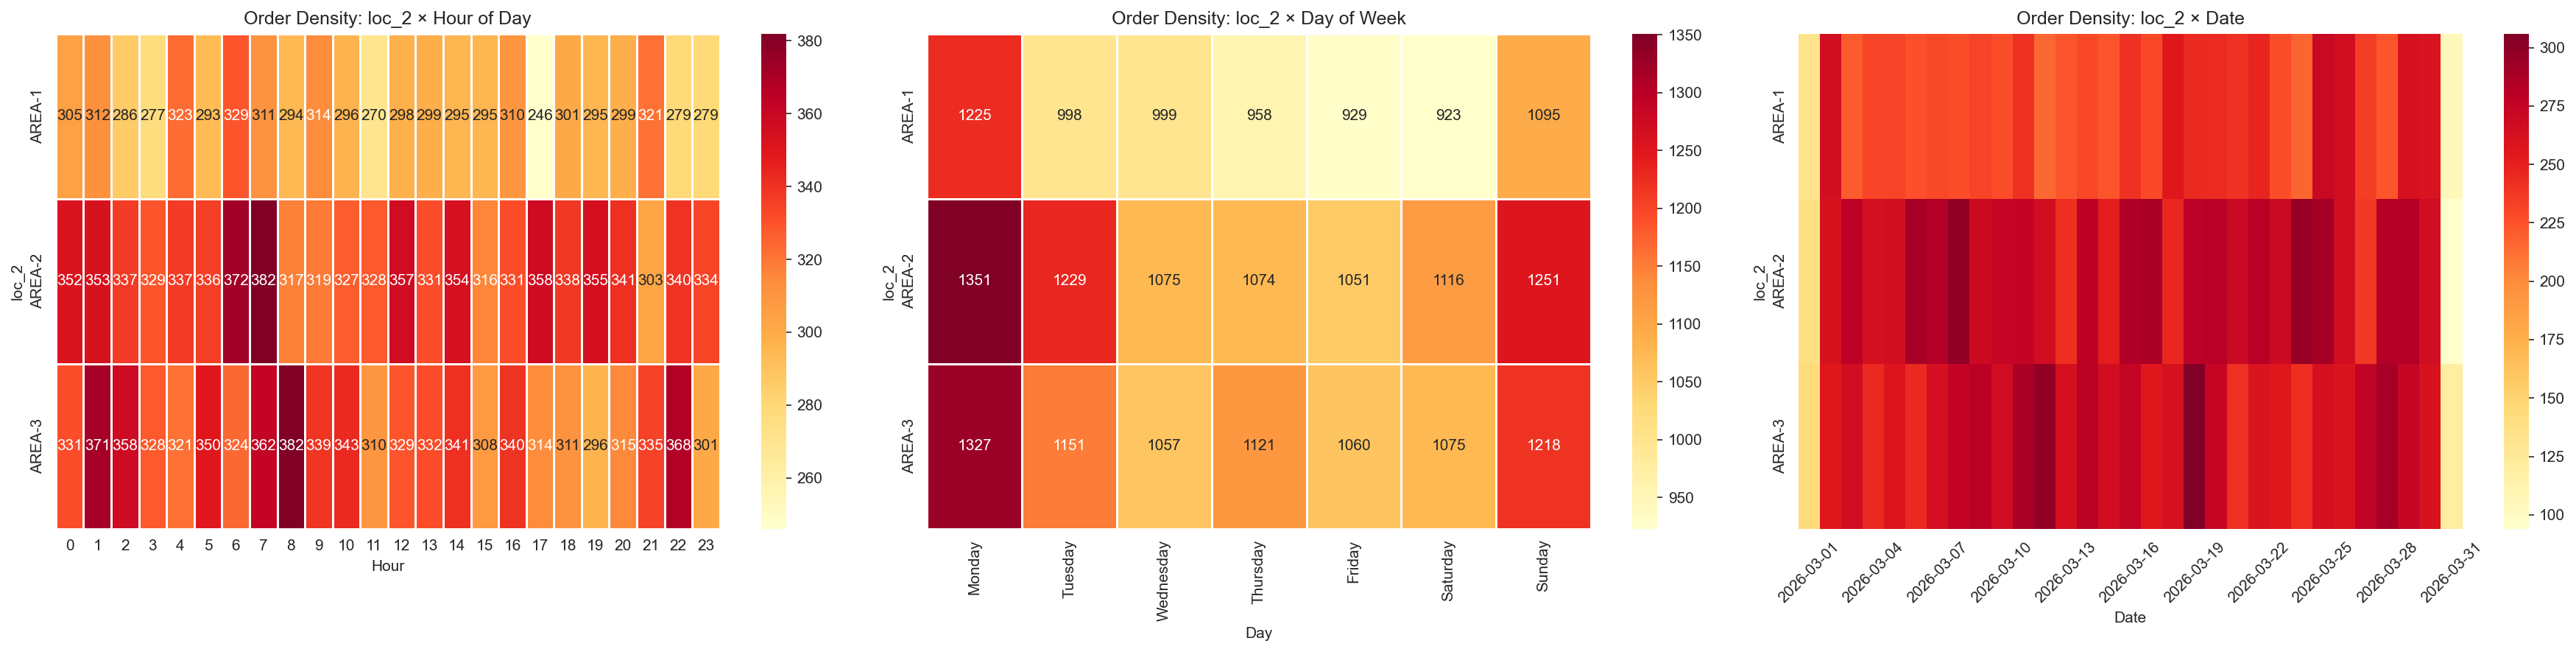

Peak hour: 1:00 (1,322 orders)
Daily volume: min=421, max=1055, mean=968


In [7]:
# Usage heatmap: loc_2 × hour / day-of-week / date
df['hour'] = df['order_created_at'].dt.hour
df['date'] = df['order_created_at'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Left: loc_2 × hour
loc2_hour = df.dropna(subset=['loc_2']).groupby(['loc_2', 'hour']).size().unstack(fill_value=0)
sns.heatmap(loc2_hour, cmap='YlOrRd', annot=True, fmt='d', ax=axes[0], linewidths=0.5)
axes[0].set_title('Order Density: loc_2 × Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('loc_2')

# Middle: loc_2 × day-of-week
df['dow'] = df['order_created_at'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
loc2_dow = df.dropna(subset=['loc_2']).groupby(['loc_2', 'dow']).size().unstack(fill_value=0)
loc2_dow = loc2_dow.reindex(columns=[d for d in dow_order if d in loc2_dow.columns], fill_value=0)
sns.heatmap(loc2_dow, cmap='YlOrRd', annot=True, fmt='d', ax=axes[1], linewidths=0.5)
axes[1].set_title('Order Density: loc_2 × Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('loc_2')

# Right: loc_2 × date (daily volume)
loc2_date = df.dropna(subset=['loc_2']).groupby(['loc_2', 'date']).size().unstack(fill_value=0)
sns.heatmap(loc2_date, cmap='YlOrRd', ax=axes[2], linewidths=0,
            xticklabels=max(1, len(loc2_date.columns)//10))  # show every Nth date
axes[2].set_title('Order Density: loc_2 × Date')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('loc_2')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_usage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

total_by_hour = df.groupby('hour').size()
peak_hour = total_by_hour.idxmax()
print(f"Peak hour: {peak_hour}:00 ({total_by_hour[peak_hour]:,} orders)")

daily_total = df.groupby('date').size()
print(f"Daily volume: min={daily_total.min()}, max={daily_total.max()}, mean={daily_total.mean():.0f}")


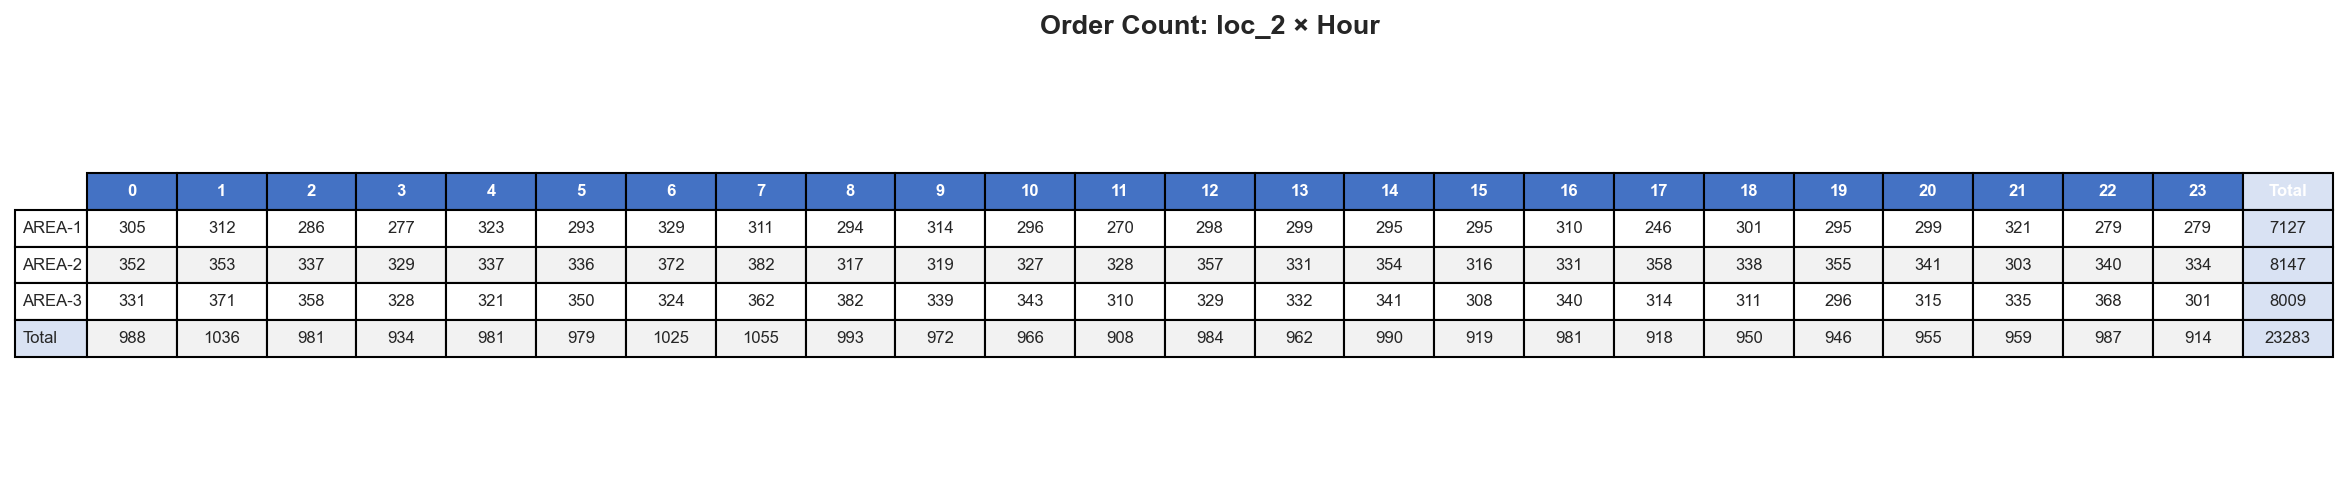

Saved: ../reports/step1_table_loc2_hour.png


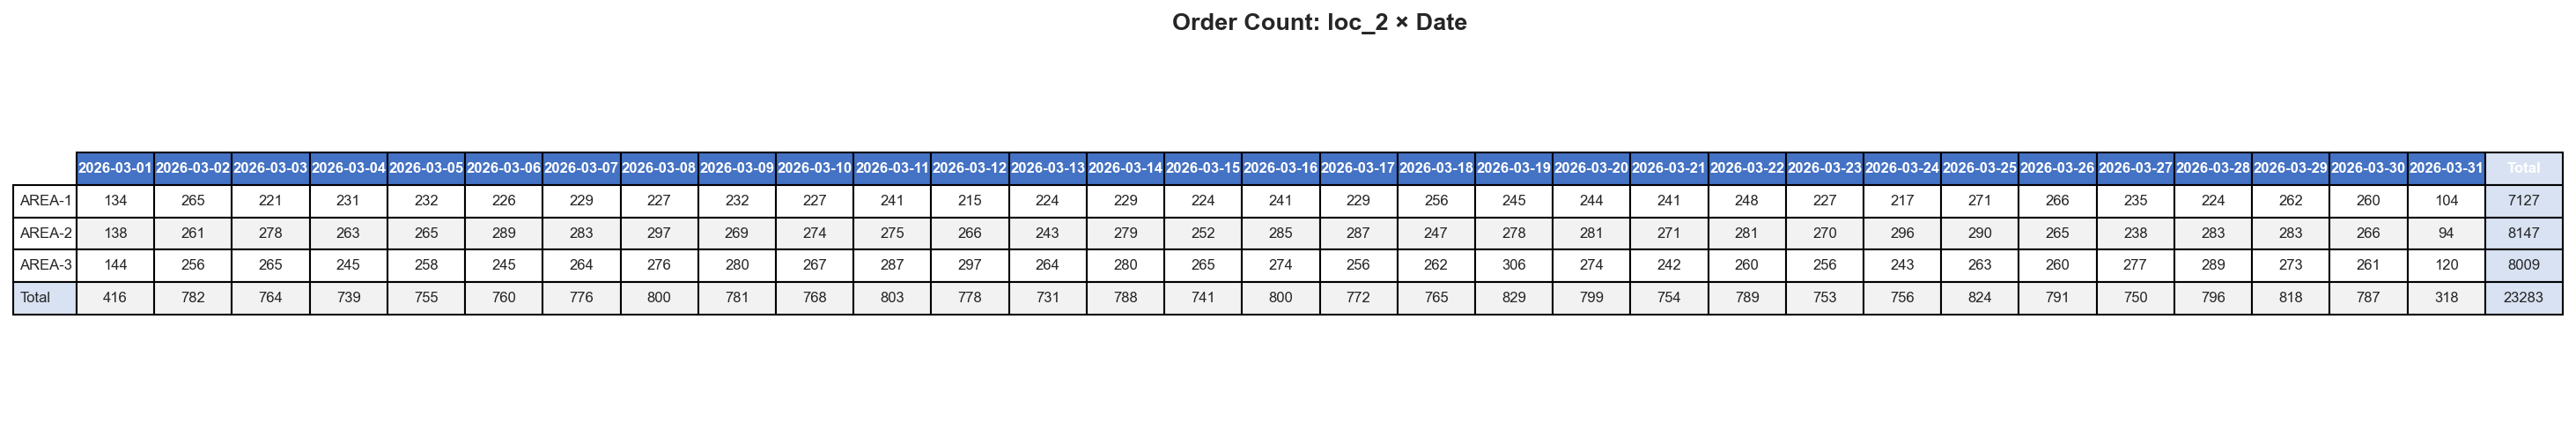

Saved: ../reports/step1_table_loc2_date.png


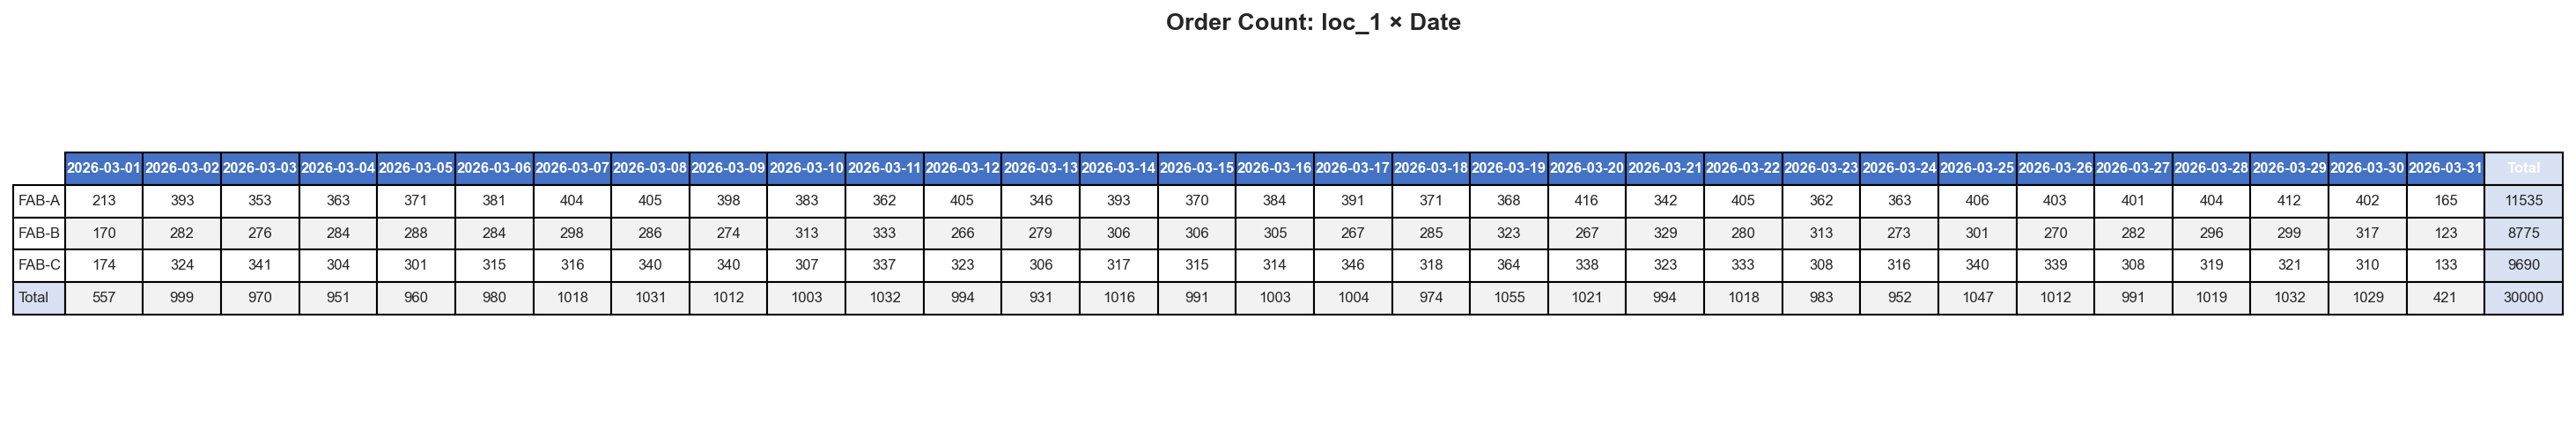

Saved: ../reports/step1_table_loc1_date.png
Saved: reports/step1_usage_tables.txt


In [8]:
# Crosstab tables (比 heatmap 更清楚)

# Build tables
loc2_date_table = df.dropna(subset=['loc_2']).groupby(['loc_2', 'date']).size().unstack(fill_value=0)
loc2_date_table['Total'] = loc2_date_table.sum(axis=1)
daily_total = loc2_date_table.sum(axis=0)
daily_total.name = 'Total'
loc2_date_table = pd.concat([loc2_date_table, daily_total.to_frame().T])

loc2_hour_table = df.dropna(subset=['loc_2']).groupby(['loc_2', 'hour']).size().unstack(fill_value=0)
loc2_hour_table['Total'] = loc2_hour_table.sum(axis=1)
hourly_total = loc2_hour_table.sum(axis=0)
hourly_total.name = 'Total'
loc2_hour_table = pd.concat([loc2_hour_table, hourly_total.to_frame().T])

loc1_date_table = df.groupby(['loc_1', 'date']).size().unstack(fill_value=0)
loc1_date_table['Total'] = loc1_date_table.sum(axis=1)
daily_total_1 = loc1_date_table.sum(axis=0)
daily_total_1.name = 'Total'
loc1_date_table = pd.concat([loc1_date_table, daily_total_1.to_frame().T])

# Render as table images
def table_to_image(table, title, filepath, date_cols=False):
    col_labels = [str(c).split(' ')[0] if date_cols and c != 'Total' else str(c) for c in table.columns]
    n_cols = len(col_labels)
    n_rows = len(table)
    
    fig_w = max(8, n_cols * 0.55 + 2)
    fig_h = max(2, n_rows * 0.45 + 1.5)
    
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    
    cell_text = table.values.astype(int).astype(str).tolist()
    row_labels = [str(r) for r in table.index]
    
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, rowLabels=row_labels,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    
    # Style: header row
    for j in range(n_cols):
        tbl[0, j].set_facecolor('#4472C4')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    # Style: Total column
    for r in range(n_rows + 1):
        tbl[r, n_cols - 1].set_facecolor('#D9E2F3')
    # Style: Total row
    for j in range(-1, n_cols):
        tbl[n_rows, j].set_facecolor('#D9E2F3')
    # Style: alternating row colors
    for r in range(1, n_rows + 1):
        for j in range(n_cols):
            if r % 2 == 0 and j != n_cols - 1:
                tbl[r, j].set_facecolor('#F2F2F2')
    
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filepath}")

table_to_image(loc2_hour_table, 'Order Count: loc_2 × Hour', 
               str(REPORTS_DIR / 'step1_table_loc2_hour.png'))

table_to_image(loc2_date_table, 'Order Count: loc_2 × Date',
               str(REPORTS_DIR / 'step1_table_loc2_date.png'), date_cols=True)

table_to_image(loc1_date_table, 'Order Count: loc_1 × Date',
               str(REPORTS_DIR / 'step1_table_loc1_date.png'), date_cols=True)

# Also export as text
with open(str(REPORTS_DIR / 'step1_usage_tables.txt'), 'w') as f:
    f.write("=== Order Count: loc_2 × Date ===\n")
    f.write(loc2_date_table.to_string())
    f.write("\n\n=== Order Count: loc_2 × Hour ===\n")
    f.write(loc2_hour_table.to_string())
    f.write("\n\n=== Order Count: loc_1 × Date ===\n")
    f.write(loc1_date_table.to_string())
print(f"Saved: reports/step1_usage_tables.txt")


## Part B — Contention Detection

同 device 在 `[t, t + WINDOW]` 內有 `>= MIN_ORDERS` 筆 order → contention

Contention orders: 159 / 30,000 (0.5%)
Devices with contention: 98


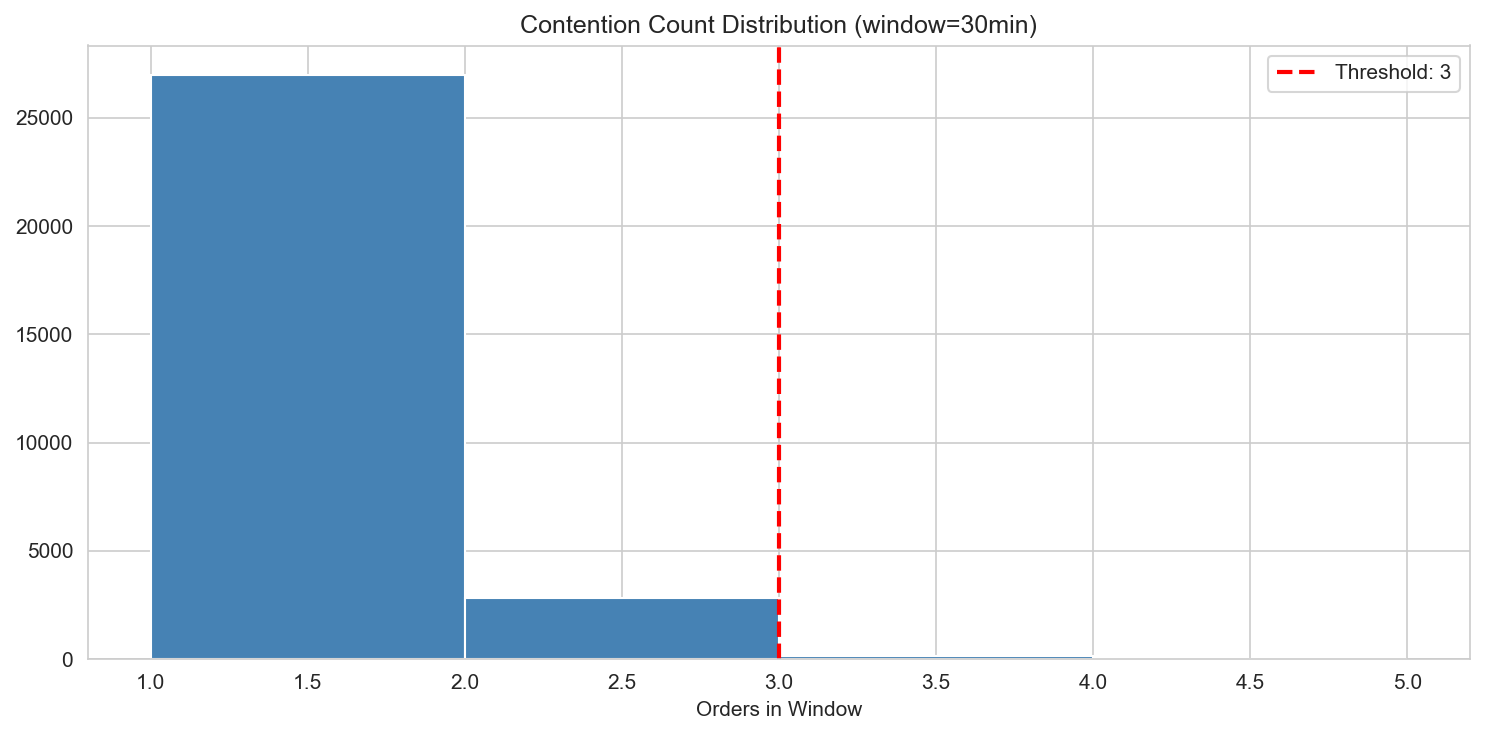

In [9]:
# Contention detection
df = df.sort_values(['device_id', 'order_created_at']).reset_index(drop=True)

def detect_contention(group):
    times = group['order_created_at'].values
    counts = []
    for i, t in enumerate(times):
        window_end = t + np.timedelta64(CONTENTION_WINDOW_MINUTES, 'm')
        count = ((times >= t) & (times <= window_end)).sum()
        counts.append(count)
    return pd.Series(counts, index=group.index)

df['contention_count'] = df.groupby('device_id', group_keys=False).apply(detect_contention)
df['is_user_anomaly'] = df['contention_count'] >= CONTENTION_MIN_ORDERS

contention = df[df['is_user_anomaly']]
print(f"Contention orders: {len(contention):,} / {len(df):,} ({100*len(contention)/len(df):.1f}%)")
print(f"Devices with contention: {contention['device_id'].nunique()}")

# Histogram of contention count
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['contention_count'], bins=range(1, df['contention_count'].max()+2),
        color='steelblue', edgecolor='white')
ax.axvline(x=CONTENTION_MIN_ORDERS, color='red', linestyle='--', linewidth=2,
           label=f'Threshold: {CONTENTION_MIN_ORDERS}')
ax.set_title(f'Contention Count Distribution (window={CONTENTION_WINDOW_MINUTES}min)')
ax.set_xlabel('Orders in Window')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_contention_count.png', dpi=150)
plt.show()


## Part C — Uplift Validation

**關鍵問題**：contention 是否真的造成 device_duration 偏高？
計算 per-device uplift = contention orders 的 device_duration median / non-contention median

Devices with both contention and normal orders: 98

Uplift distribution (contention_device_dur / normal_device_dur):
  P25=0.82, P50=1.00, P75=1.48, mean=1.10


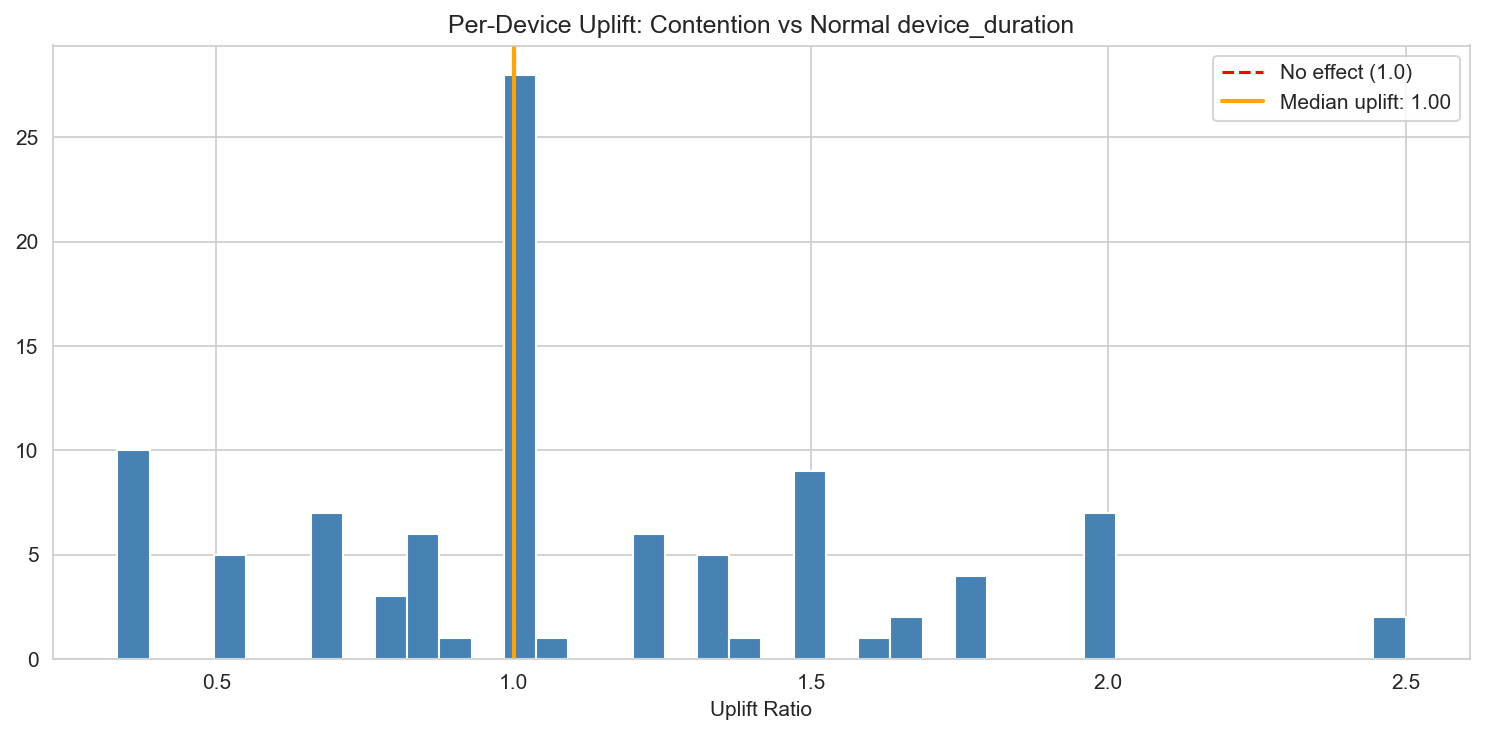


ℹ️  Contention 無明顯影響 (uplift=1.00x)
   → 建議調整參數（縮小 window 或提高 min_orders）
   → 或跳過 Layer 1b（將所有 is_user_anomaly 設為 False）


In [10]:
# Per-device uplift validation
devices_with_both = df.groupby('device_id')['is_user_anomaly'].agg(['sum', 'count'])
devices_with_both = devices_with_both[(devices_with_both['sum'] > 0) &
                                      (devices_with_both['sum'] < devices_with_both['count'])]
valid_devices = devices_with_both.index

if len(valid_devices) == 0:
    print("⚠️  沒有 device 同時有 contention 和 non-contention orders")
    print("   → 無法計算 uplift，考慮調整 CONTENTION_WINDOW_MINUTES 或 CONTENTION_MIN_ORDERS")
    uplift_median = 1.0
else:
    uplifts = []
    for dev in valid_devices:
        dev_data = df[df['device_id'] == dev]
        cont_med = dev_data.loc[dev_data['is_user_anomaly'], 'device_duration_avg_seconds'].median()
        norm_med = dev_data.loc[~dev_data['is_user_anomaly'], 'device_duration_avg_seconds'].median()
        if norm_med > 0:
            uplifts.append({'device_id': dev, 'uplift': cont_med / norm_med,
                           'cont_median': cont_med, 'norm_median': norm_med})

    uplift_df = pd.DataFrame(uplifts)
    uplift_median = uplift_df['uplift'].median()

    print(f"Devices with both contention and normal orders: {len(uplift_df)}")
    print(f"\nUplift distribution (contention_device_dur / normal_device_dur):")
    print(f"  P25={uplift_df['uplift'].quantile(0.25):.2f}, "
          f"P50={uplift_df['uplift'].median():.2f}, "
          f"P75={uplift_df['uplift'].quantile(0.75):.2f}, "
          f"mean={uplift_df['uplift'].mean():.2f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(uplift_df['uplift'], bins=40, color='steelblue', edgecolor='white')
    ax.axvline(x=1.0, color='red', linestyle='--', label='No effect (1.0)')
    ax.axvline(x=uplift_median, color='orange', linestyle='-', linewidth=2,
               label=f'Median uplift: {uplift_median:.2f}')
    ax.set_title('Per-Device Uplift: Contention vs Normal device_duration')
    ax.set_xlabel('Uplift Ratio')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'step1_uplift.png', dpi=150)
    plt.show()

# Verdict
print("\n" + "=" * 60)
if uplift_median > 1.3:
    print(f"✅ Contention 造成 device_duration 偏高 (uplift={uplift_median:.2f}x)")
    print(f"   → Layer 1b contention 偵測有效，保留標記")
elif uplift_median > 1.1:
    print(f"⚠️  Contention 有輕微影響 (uplift={uplift_median:.2f}x)")
    print(f"   → 可保留標記，但影響不大")
else:
    print(f"ℹ️  Contention 無明顯影響 (uplift={uplift_median:.2f}x)")
    print(f"   → 建議調整參數（縮小 window 或提高 min_orders）")
    print(f"   → 或跳過 Layer 1b（將所有 is_user_anomaly 設為 False）")
print("=" * 60)


## 匯出

In [11]:
# Export
user_flags = df[['order_id', 'is_user_anomaly']].copy()
user_flags.to_csv('../data/user_anomaly_flags.csv', index=False)
print(f"Exported: data/user_anomaly_flags.csv ({user_flags['is_user_anomaly'].sum():,} contention orders)")

print(f"\n=== Step 1 Summary ===")
print(f"Total orders: {len(df):,}")
print(f"Contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")
print(f"Params: window={CONTENTION_WINDOW_MINUTES}min, min_orders={CONTENTION_MIN_ORDERS}")
print(f"Uplift median: {uplift_median:.2f}x")


Exported: data/user_anomaly_flags.csv (159 contention orders)

=== Step 1 Summary ===
Total orders: 30,000
Contention: 159 (0.5%)
Params: window=30min, min_orders=3
Uplift median: 1.00x


In [12]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 1 — EDA + User Contention")
summary.append("=" * 60)
summary.append(f"\nTotal orders: {len(df):,}")
summary.append(f"Contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")
summary.append(f"Params: window={CONTENTION_WINDOW_MINUTES}min, min_orders={CONTENTION_MIN_ORDERS}")
summary.append(f"Uplift median: {uplift_median:.2f}x")
if uplift_median > 1.3:
    summary.append(f"Verdict: Contention 有影響")
elif uplift_median > 1.1:
    summary.append(f"Verdict: Contention 輕微影響")
else:
    summary.append(f"Verdict: Contention 無明顯影響")

summary.append(f"\nPhase Percentiles:")
for col, title in phase_cols.items():
    pcts = df[col].quantile([0.5, 0.95, 0.99])
    summary.append(f"  {title}: P50={pcts[0.5]:.0f}, P95={pcts[0.95]:.0f}, P99={pcts[0.99]:.0f}")

summary.append(f"\nDevice models: {df['device_mode_name'].nunique()} types + {df['device_mode_name'].isnull().mean()*100:.1f}% null")
summary.append(f"Peak hour: {peak_hour}:00")

with open(str(REPORTS_DIR / 'step1_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step1_summary.txt")

Saved: reports/step1_summary.txt
